# CNN Exercise with TensorFlow — From 0 to Hero 🧠🧪

**Last updated:** 2025-10-01 09:23 UTC  

This notebook takes you from zero to hero on Convolutional Neural Networks (CNNs) using TensorFlow/Keras.
It includes **exercises** followed by **corrections/solutions**. Work through the *Exercise* cells first, then reveal the *Correction* cells.

---
### What you'll learn
1. CNN fundamentals and when to use them
2. Loading and preparing image datasets (MNIST + CIFAR-10)
3. Building, training, and evaluating CNNs with TensorFlow/Keras
4. Improving models: regularization, data augmentation, callbacks
5. Visualizing results: confusion matrix, learning curves
6. (Bonus) Transfer learning with a pretrained network

> Tip: Run this notebook top-to-bottom the first time. Then iterate and experiment!

## 0. Setup

In [ ]:
!pip install tensorflow

In [2]:
# If running on Colab, uncomment the next line to ensure latest TF is installed
# !pip install -q tensorflow tensorflow-datasets

import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import itertools
from sklearn.metrics import confusion_matrix, classification_report
print("TensorFlow:", tf.__version__)

TensorFlow: 2.18.0


## 0.1 Utility functions

In [3]:
import time

def plot_samples(images, labels, class_names=None, n=8):
    plt.figure(figsize=(12, 2))
    for i in range(n):
        plt.subplot(1, n, i+1)
        plt.imshow(images[i].squeeze(), cmap='gray' if images[i].ndim==2 or images[i].shape[-1]==1 else None)
        plt.axis('off')
        title = str(labels[i])
        if class_names is not None:
            title = class_names[labels[i]]
        plt.title(title)
    plt.show()

def plot_history(history):
    hist = history.history
    epochs = range(1, len(hist['loss'])+1)
    plt.figure()
    plt.plot(epochs, hist['loss'], label='train_loss')
    plt.plot(epochs, hist.get('val_loss', []), label='val_loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.title('Loss')
    plt.show()

    plt.figure()
    plt.plot(epochs, hist.get('accuracy', []), label='train_acc')
    plt.plot(epochs, hist.get('val_accuracy', []), label='val_acc')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.title('Accuracy')
    plt.show()

def plot_confusion_matrix(cm, class_names):
    plt.figure(figsize=(6, 6))
    plt.imshow(cm, interpolation='nearest')
    plt.title('Confusion Matrix')
    plt.colorbar()
    tick_marks = np.arange(len(class_names))
    plt.xticks(tick_marks, class_names, rotation=45, ha='right')
    plt.yticks(tick_marks, class_names)
    thresh = cm.max() / 2.
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, format(cm[i, j], 'd'),
                 horizontalalignment="center",
                 color="white" if cm[i, j] > thresh else "black")
    plt.tight_layout()
    plt.ylabel('True label')
    plt.xlabel('Predicted label')
    plt.show()

## 1. Warm‑up: MNIST Digit Classification

### Exercise 1 — Load and inspect the MNIST dataset
- Load MNIST from `tf.keras.datasets.mnist`
- Show the shapes of train/test sets
- Plot a few samples

*(Do this below, then compare with the correction)*

In [4]:
# === Your work: Exercise 1 ===
from tensorflow.keras.datasets import mnist

# TODO: load data
# (x_train, y_train), (x_test, y_test) = ...

# TODO: inspect shapes

# TODO: visualize few samples using plot_samples
# plot_samples(x_train, y_train, n=10)

#### ✅ Correction — Exercise 1

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 6s 1us/step
(60000, 28, 28) (60000,) (10000, 28, 28) (10000,)


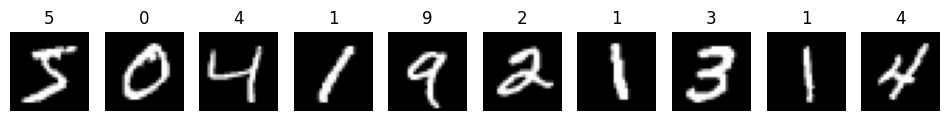

In [5]:
from tensorflow.keras.datasets import mnist
(x_train, y_train), (x_test, y_test) = mnist.load_data()
print(x_train.shape, y_train.shape, x_test.shape, y_test.shape)
plot_samples(x_train, y_train, n=10)

### Exercise 2 — Preprocess data for CNN
- Normalize pixel values to [0,1]
- Expand channel dimension to (H, W, 1)
- Convert labels to integers (already are), keep as is

Why? CNNs expect channel dims and normalized inputs for stable training.

In [ ]:
# === Your work: Exercise 2 ===
# x_train = ...
# x_test  = ...
# x_train = np.expand_dims(x_train, -1)
# x_test  = np.expand_dims(x_test, -1)
# y_train, y_test = y_train.astype('int32'), y_test.astype('int32')

#### ✅ Correction — Exercise 2

In [6]:
x_train = x_train.astype('float32')/255.0
x_test  = x_test.astype('float32')/255.0
x_train = np.expand_dims(x_train, -1)
x_test  = np.expand_dims(x_test, -1)
y_train = y_train.astype('int32')
y_test  = y_test.astype('int32')
x_train.shape, x_test.shape

((60000, 28, 28, 1), (10000, 28, 28, 1))

### Exercise 3 — Build a small CNN with Keras
- Use `Conv2D` → `ReLU` → `MaxPool` stacks
- Add `Dropout` for regularization
- End with `Flatten` → `Dense`(10, softmax)

In [7]:
# === Your work: Exercise 3 ===
from tensorflow.keras import layers, models

# model = models.Sequential([
#     layers.Input(shape=(28,28,1)),
#     # TODO: Conv/Pool stack(s)
#     # layers.Conv2D(32, 3, activation='relu'),
#     # layers.MaxPooling2D(),
#     # layers.Conv2D(64, 3, activation='relu'),
#     # layers.MaxPooling2D(),
#     # layers.Dropout(0.25),
#     # layers.Flatten(),
#     # layers.Dense(128, activation='relu'),
#     # layers.Dropout(0.5),
#     # layers.Dense(10, activation='softmax')
# ])
# model.summary()

#### ✅ Correction — Exercise 3

In [8]:
from tensorflow.keras import layers, models
model = models.Sequential([
    layers.Input(shape=(28,28,1)),
    layers.Conv2D(32, 3, activation='relu'),
    layers.MaxPooling2D(),
    layers.Conv2D(64, 3, activation='relu'),
    layers.MaxPooling2D(),
    layers.Dropout(0.25),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(10, activation='softmax')
])
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

### Exercise 4 — Compile and train
- Use `SparseCategoricalCrossentropy`
- Metrics: `accuracy`
- Train for ~5–10 epochs

In [ ]:
# === Your work: Exercise 4 ===
# model.compile(optimizer='adam',
#               loss='sparse_categorical_crossentropy',
#               metrics=['accuracy'])
# history = model.fit(x_train, y_train, validation_split=0.1, epochs=5, batch_size=128)
# plot_history(history)

#### ✅ Correction — Exercise 4

Epoch 1/5
422/422 - 9s - 21ms/step - accuracy: 0.8944 - loss: 0.3408 - val_accuracy: 0.9818 - val_loss: 0.0624
Epoch 2/5
422/422 - 8s - 19ms/step - accuracy: 0.9656 - loss: 0.1107 - val_accuracy: 0.9873 - val_loss: 0.0435
Epoch 3/5
422/422 - 8s - 20ms/step - accuracy: 0.9757 - loss: 0.0806 - val_accuracy: 0.9898 - val_loss: 0.0359
Epoch 4/5
422/422 - 8s - 19ms/step - accuracy: 0.9791 - loss: 0.0686 - val_accuracy: 0.9898 - val_loss: 0.0352
Epoch 5/5
422/422 - 8s - 19ms/step - accuracy: 0.9822 - loss: 0.0586 - val_accuracy: 0.9912 - val_loss: 0.0328


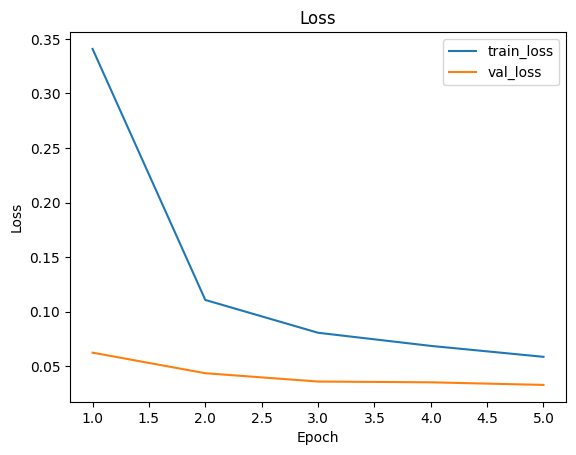

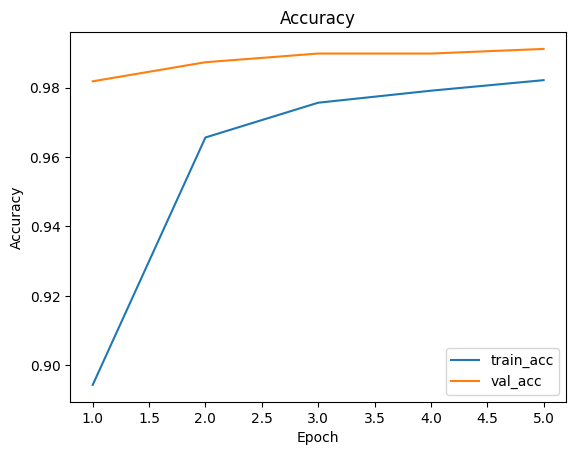

In [9]:
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])
history = model.fit(x_train, y_train, validation_split=0.1, epochs=5, batch_size=128, verbose=2)
plot_history(history)

### Exercise 5 — Evaluate and error analysis
- Evaluate on test set
- Compute confusion matrix and classification report

In [ ]:
# === Your work: Exercise 5 ===
# test_loss, test_acc = model.evaluate(x_test, y_test, verbose=0)
# print("Test acc:", test_acc)

# y_pred = np.argmax(model.predict(x_test, verbose=0), axis=1)
# cm = confusion_matrix(y_test, y_pred)
# plot_confusion_matrix(cm, class_names=[str(i) for i in range(10)])
# print(classification_report(y_test, y_pred))

#### ✅ Correction — Exercise 5

Test accuracy: 0.9915


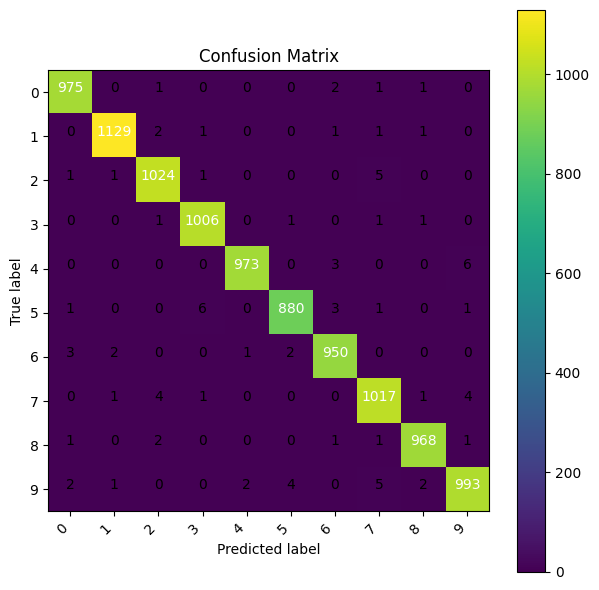

              precision    recall  f1-score   support

           0       0.99      0.99      0.99       980
           1       1.00      0.99      1.00      1135
           2       0.99      0.99      0.99      1032
           3       0.99      1.00      0.99      1010
           4       1.00      0.99      0.99       982
           5       0.99      0.99      0.99       892
           6       0.99      0.99      0.99       958
           7       0.99      0.99      0.99      1028
           8       0.99      0.99      0.99       974
           9       0.99      0.98      0.99      1009

    accuracy                           0.99     10000
   macro avg       0.99      0.99      0.99     10000
weighted avg       0.99      0.99      0.99     10000



In [10]:
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=0)
print("Test accuracy:", round(float(test_acc), 4))

y_pred = np.argmax(model.predict(x_test, verbose=0), axis=1)
cm = confusion_matrix(y_test, y_pred)
plot_confusion_matrix(cm, class_names=[str(i) for i in range(10)])
print(classification_report(y_test, y_pred))

## 2. Make it better: Regularization, Callbacks, and Data Augmentation

### Exercise 6 — Add callbacks and early stopping
- Add `EarlyStopping(monitor='val_loss', patience=2, restore_best_weights=True)`
- Re-train the model and compare learning curves

In [ ]:
# === Your work: Exercise 6 ===
# from tensorflow.keras.callbacks import EarlyStopping
# es = EarlyStopping(monitor='val_loss', patience=2, restore_best_weights=True)
# history2 = model.fit(x_train, y_train, validation_split=0.1, epochs=12, batch_size=128, callbacks=[es], verbose=2)
# plot_history(history2)

#### ✅ Correction — Exercise 6

Epoch 1/12
422/422 - 8s - 18ms/step - accuracy: 0.9843 - loss: 0.0505 - val_accuracy: 0.9907 - val_loss: 0.0335
Epoch 2/12
422/422 - 7s - 17ms/step - accuracy: 0.9853 - loss: 0.0464 - val_accuracy: 0.9908 - val_loss: 0.0349
Epoch 3/12
422/422 - 9s - 22ms/step - accuracy: 0.9874 - loss: 0.0400 - val_accuracy: 0.9922 - val_loss: 0.0308
Epoch 4/12
422/422 - 9s - 21ms/step - accuracy: 0.9878 - loss: 0.0376 - val_accuracy: 0.9923 - val_loss: 0.0288
Epoch 5/12
422/422 - 8s - 18ms/step - accuracy: 0.9884 - loss: 0.0359 - val_accuracy: 0.9928 - val_loss: 0.0303
Epoch 6/12
422/422 - 8s - 18ms/step - accuracy: 0.9899 - loss: 0.0334 - val_accuracy: 0.9930 - val_loss: 0.0289


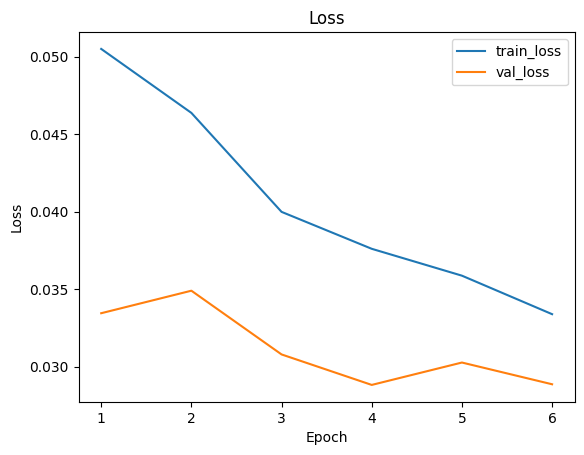

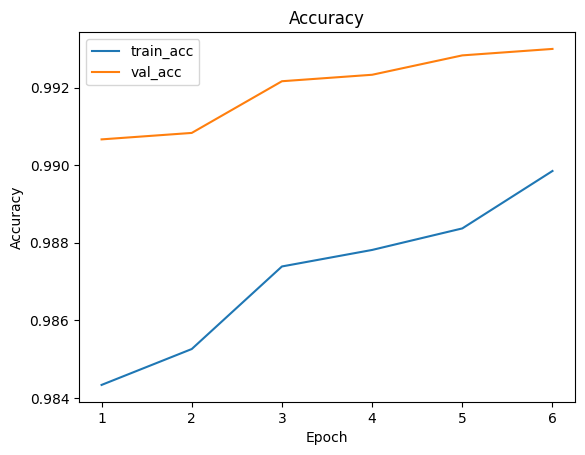

In [11]:
from tensorflow.keras.callbacks import EarlyStopping
es = EarlyStopping(monitor='val_loss', patience=2, restore_best_weights=True)
history2 = model.fit(x_train, y_train, validation_split=0.1, epochs=12, batch_size=128, callbacks=[es], verbose=2)
plot_history(history2)

### Exercise 7 — Data augmentation
Use `tf.keras.preprocessing.image.ImageDataGenerator` **or** `tf.keras.layers.Random*` preprocessing layers.
Try random rotations, shifts, and flips. Re-train and evaluate.

In [ ]:
# === Your work: Exercise 7 ===
# from tensorflow.keras import layers
# data_augmentation = tf.keras.Sequential([
#     layers.RandomRotation(0.05),
#     layers.RandomTranslation(0.05, 0.05),
#     layers.RandomZoom(0.05)
# ])
# aug_model = models.Sequential([
#     layers.Input(shape=(28,28,1)),
#     data_augmentation,
#     layers.Conv2D(32, 3, activation='relu'),
#     layers.MaxPooling2D(),
#     layers.Conv2D(64, 3, activation='relu'),
#     layers.MaxPooling2D(),
#     layers.Flatten(),
#     layers.Dense(128, activation='relu'),
#     layers.Dense(10, activation='softmax')
# ])
# aug_model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
# history_aug = aug_model.fit(x_train, y_train, validation_split=0.1, epochs=5, batch_size=128, verbose=2)
# plot_history(history_aug)

#### ✅ Correction — Exercise 7

Epoch 1/5
422/422 - 13s - 30ms/step - accuracy: 0.8965 - loss: 0.3409 - val_accuracy: 0.9767 - val_loss: 0.0772
Epoch 2/5
422/422 - 11s - 26ms/step - accuracy: 0.9626 - loss: 0.1212 - val_accuracy: 0.9862 - val_loss: 0.0473
Epoch 3/5
422/422 - 11s - 26ms/step - accuracy: 0.9717 - loss: 0.0894 - val_accuracy: 0.9893 - val_loss: 0.0375
Epoch 4/5
422/422 - 11s - 26ms/step - accuracy: 0.9774 - loss: 0.0736 - val_accuracy: 0.9852 - val_loss: 0.0479
Epoch 5/5
422/422 - 11s - 26ms/step - accuracy: 0.9809 - loss: 0.0608 - val_accuracy: 0.9882 - val_loss: 0.0405


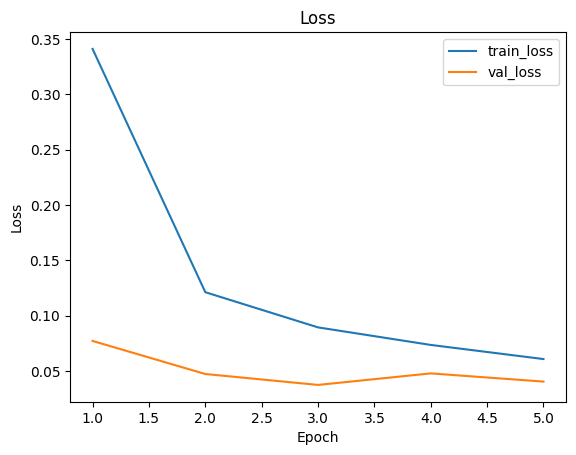

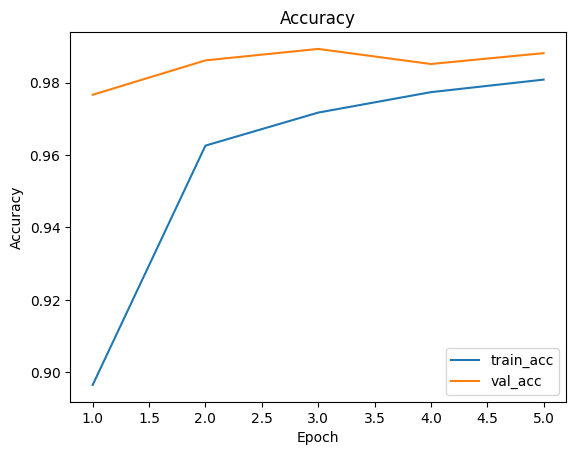

In [12]:
from tensorflow.keras import layers
data_augmentation = tf.keras.Sequential([
    layers.RandomRotation(0.05),
    layers.RandomTranslation(0.05, 0.05),
    layers.RandomZoom(0.05)
])
aug_model = models.Sequential([
    layers.Input(shape=(28,28,1)),
    data_augmentation,
    layers.Conv2D(32, 3, activation='relu'),
    layers.MaxPooling2D(),
    layers.Conv2D(64, 3, activation='relu'),
    layers.MaxPooling2D(),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(10, activation='softmax')
])
aug_model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
history_aug = aug_model.fit(x_train, y_train, validation_split=0.1, epochs=5, batch_size=128, verbose=2)
plot_history(history_aug)

## 3. Level up: CIFAR‑10 (color images, 10 classes)

We'll switch to CIFAR‑10 which is more challenging: color images (32×32×3) with 10 object classes.

### Exercise 8 — Load and preview CIFAR‑10

In [13]:
# === Your work: Exercise 8 ===
from tensorflow.keras.datasets import cifar10

# TODO: load data
# (x_train_c, y_train_c), (x_test_c, y_test_c) = ...

# TODO: normalize to [0,1] and preview a few samples with class names
# class_names = ['airplane','automobile','bird','cat','deer','dog','frog','horse','ship','truck']
# plot_samples(x_train_c, y_train_c, class_names=class_names, n=10)

#### ✅ Correction — Exercise 8

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 94s 1us/step


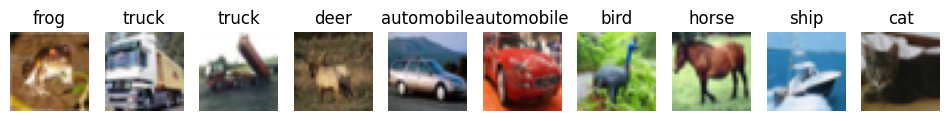

((50000, 32, 32, 3), (50000,))

In [14]:
from tensorflow.keras.datasets import cifar10
(x_train_c, y_train_c), (x_test_c, y_test_c) = cifar10.load_data()
y_train_c = y_train_c.flatten().astype('int32')
y_test_c  = y_test_c.flatten().astype('int32')
x_train_c = x_train_c.astype('float32')/255.0
x_test_c  = x_test_c.astype('float32')/255.0
class_names = ['airplane','automobile','bird','cat','deer','dog','frog','horse','ship','truck']
plot_samples(x_train_c, y_train_c, class_names=class_names, n=10)
x_train_c.shape, y_train_c.shape

### Exercise 9 — Build a deeper CNN for CIFAR‑10
Try: `Conv → Conv → MaxPool` blocks, with BatchNorm and Dropout.

In [ ]:
# === Your work: Exercise 9 ===
# from tensorflow.keras import layers, models
# def make_cifar_model():
#     inputs = layers.Input(shape=(32,32,3))
#     x = layers.Conv2D(32, 3, padding='same', activation='relu')(inputs)
#     x = layers.Conv2D(32, 3, padding='same', activation='relu')(x)
#     x = layers.MaxPooling2D()(x)
#     x = layers.Dropout(0.25)(x)

#     x = layers.Conv2D(64, 3, padding='same', activation='relu')(x)
#     x = layers.Conv2D(64, 3, padding='same', activation='relu')(x)
#     x = layers.MaxPooling2D()(x)
#     x = layers.Dropout(0.25)(x)

#     x = layers.Flatten()(x)
#     x = layers.Dense(256, activation='relu')(x)
#     x = layers.Dropout(0.5)(x)
#     outputs = layers.Dense(10, activation='softmax')(x)
#     model = models.Model(inputs, outputs)
#     return model

# cifar_model = make_cifar_model()
# cifar_model.summary()

#### ✅ Correction — Exercise 9

In [15]:
from tensorflow.keras import layers, models
def make_cifar_model():
    inputs = layers.Input(shape=(32,32,3))
    x = layers.Conv2D(32, 3, padding='same', activation='relu')(inputs)
    x = layers.Conv2D(32, 3, padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D()(x)
    x = layers.Dropout(0.25)(x)

    x = layers.Conv2D(64, 3, padding='same', activation='relu')(x)
    x = layers.Conv2D(64, 3, padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D()(x)
    x = layers.Dropout(0.25)(x)

    x = layers.Conv2D(128, 3, padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D()(x)

    x = layers.Flatten()(x)
    x = layers.Dense(256, activation='relu')(x)
    x = layers.Dropout(0.5)(x)
    outputs = layers.Dense(10, activation='softmax')(x)
    model = models.Model(inputs, outputs)
    return model

cifar_model = make_cifar_model()
cifar_model.summary()

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 667,434 (2.55 MB)

 Trainable params: 666,986 (2.54 MB)

 Non-trainable params: 448 (1.75 KB)

### Exercise 10 — Train with augmentation and callbacks

In [ ]:
# === Your work: Exercise 10 ===
# aug = tf.keras.Sequential([
#     layers.RandomFlip("horizontal"),
#     layers.RandomRotation(0.1),
#     layers.RandomZoom(0.1),
# ])
# inputs = layers.Input(shape=(32,32,3))
# x = aug(inputs)
# x = cifar_model.layers[1](x)  # (Optional) Rebuild model around aug; alternatively wrap aug in training pipeline

# cifar_model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
# es = tf.keras.callbacks.EarlyStopping(monitor='val_accuracy', patience=3, restore_best_weights=True)
# history_c = cifar_model.fit(x_train_c, y_train_c, validation_split=0.1, epochs=20, batch_size=128, callbacks=[es], verbose=2)
# plot_history(history_c)

#### ✅ Correction — Exercise 10

Epoch 1/20
352/352 - 64s - 181ms/step - accuracy: 0.3300 - loss: 1.8656 - val_accuracy: 0.2110 - val_loss: 3.3437
Epoch 2/20
352/352 - 63s - 179ms/step - accuracy: 0.4396 - loss: 1.5478 - val_accuracy: 0.5010 - val_loss: 1.4056
Epoch 3/20
352/352 - 59s - 168ms/step - accuracy: 0.5018 - loss: 1.3940 - val_accuracy: 0.5242 - val_loss: 1.3909
Epoch 4/20
352/352 - 60s - 171ms/step - accuracy: 0.5418 - loss: 1.2887 - val_accuracy: 0.5980 - val_loss: 1.1402
Epoch 5/20
352/352 - 59s - 168ms/step - accuracy: 0.5722 - loss: 1.2157 - val_accuracy: 0.6316 - val_loss: 1.0657
Epoch 6/20
352/352 - 60s - 171ms/step - accuracy: 0.5980 - loss: 1.1478 - val_accuracy: 0.6402 - val_loss: 1.0808
Epoch 7/20
352/352 - 61s - 173ms/step - accuracy: 0.6151 - loss: 1.1035 - val_accuracy: 0.6804 - val_loss: 0.9149
Epoch 8/20
352/352 - 59s - 168ms/step - accuracy: 0.6329 - loss: 1.0556 - val_accuracy: 0.6720 - val_loss: 0.9736
Epoch 9/20
352/352 - 63s - 178ms/step - accuracy: 0.6448 - loss: 1.0322 - val_accuracy: 

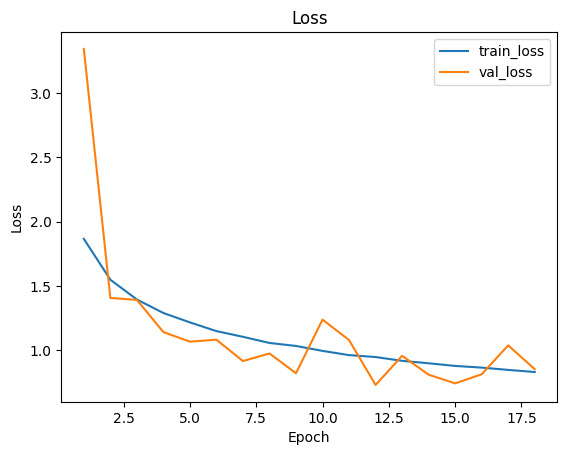

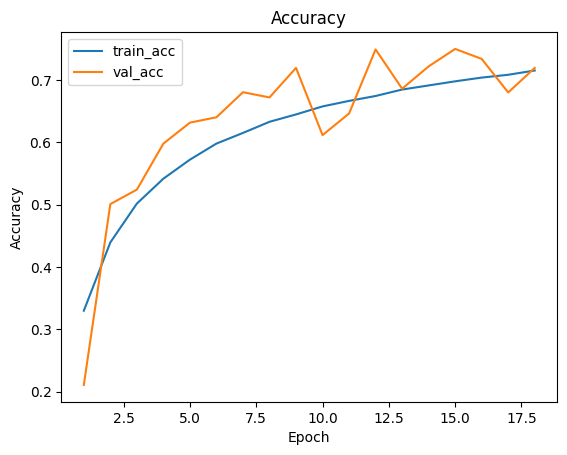

In [16]:
from tensorflow.keras import layers
aug = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
])
# Wrap augmentation into the model (functional API)
inputs = layers.Input(shape=(32,32,3))
x = aug(inputs)
x = cifar_model.layers[1](x)  # reuse architecture by calling from the second layer onward
for layer in cifar_model.layers[2:]:
    x = layer(x)
cifar_aug_model = tf.keras.Model(inputs, x)

cifar_aug_model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
es = tf.keras.callbacks.EarlyStopping(monitor='val_accuracy', patience=3, restore_best_weights=True)
history_c = cifar_aug_model.fit(x_train_c, y_train_c, validation_split=0.1, epochs=20, batch_size=128, callbacks=[es], verbose=2)
plot_history(history_c)

### Exercise 11 — Evaluate CIFAR‑10 model & error analysis

In [ ]:
# === Your work: Exercise 11 ===
# test_loss_c, test_acc_c = cifar_aug_model.evaluate(x_test_c, y_test_c, verbose=0)
# print("CIFAR-10 Test accuracy:", round(float(test_acc_c), 4))

# y_pred_c = np.argmax(cifar_aug_model.predict(x_test_c, verbose=0), axis=1)
# cm_c = confusion_matrix(y_test_c, y_pred_c)
# plot_confusion_matrix(cm_c, class_names=class_names)
# print(classification_report(y_test_c, y_pred_c, target_names=class_names))

#### ✅ Correction — Exercise 11

CIFAR-10 Test accuracy: 0.7393


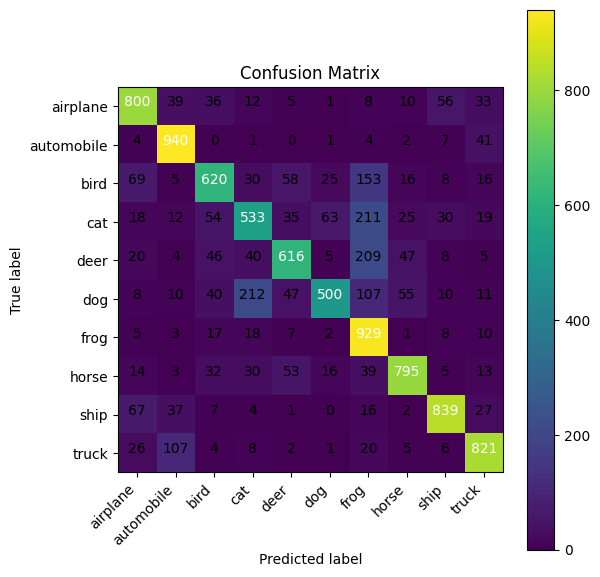

              precision    recall  f1-score   support

    airplane       0.78      0.80      0.79      1000
  automobile       0.81      0.94      0.87      1000
        bird       0.72      0.62      0.67      1000
         cat       0.60      0.53      0.56      1000
        deer       0.75      0.62      0.68      1000
         dog       0.81      0.50      0.62      1000
        frog       0.55      0.93      0.69      1000
       horse       0.83      0.80      0.81      1000
        ship       0.86      0.84      0.85      1000
       truck       0.82      0.82      0.82      1000

    accuracy                           0.74     10000
   macro avg       0.75      0.74      0.74     10000
weighted avg       0.75      0.74      0.74     10000



In [17]:
test_loss_c, test_acc_c = cifar_aug_model.evaluate(x_test_c, y_test_c, verbose=0)
print("CIFAR-10 Test accuracy:", round(float(test_acc_c), 4))

y_pred_c = np.argmax(cifar_aug_model.predict(x_test_c, verbose=0), axis=1)
cm_c = confusion_matrix(y_test_c, y_pred_c)
plot_confusion_matrix(cm_c, class_names=class_names)
print(classification_report(y_test_c, y_pred_c, target_names=class_names))

## 4. Bonus: Transfer Learning on CIFAR‑10 with MobileNetV2

We can adapt a pretrained model (MobileNetV2) to CIFAR‑10 by resizing images to 96×96 and fine‑tuning a small classification head.

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 7s 1us/step
Epoch 1/5
352/352 - 155s - 439ms/step - accuracy: 0.1020 - loss: 2.4064 - val_accuracy: 0.0970 - val_loss: 2.3060
Epoch 2/5
352/352 - 141s - 400ms/step - accuracy: 0.1070 - loss: 2.3386 - val_accuracy: 0.1272 - val_loss: 2.2974
Epoch 3/5
352/352 - 139s - 395ms/step - accuracy: 0.1117 - loss: 2.3169 - val_accuracy: 0.1126 - val_loss: 2.2925
Epoch 4/5
352/352 - 139s - 395ms/step - accuracy: 0.1226 - loss: 2.3081 - val_accuracy: 0.0982 - val_loss: 2.3003
Epoch 5/5
352/352 - 139s - 395ms/step - accuracy: 0.1229 - loss: 2.3023 - val_accuracy: 0.1406 - val_loss: 2.2748


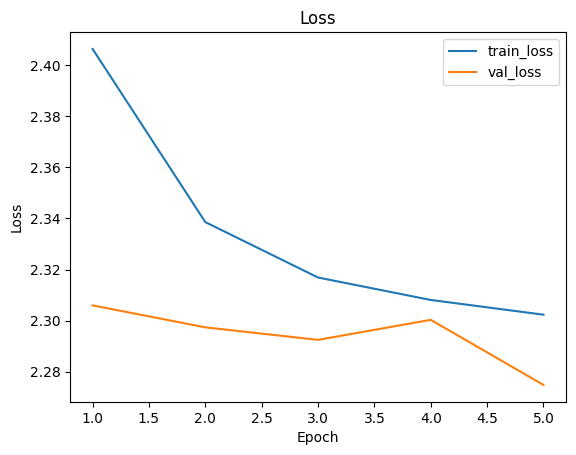

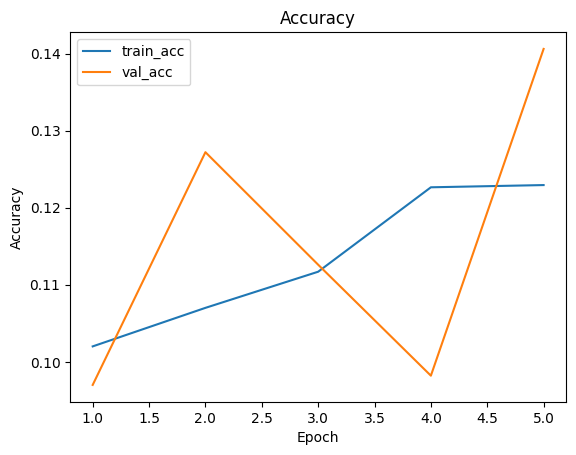

In [18]:
# This cell may take longer on CPU. Consider enabling GPU/Colab accelerator.
IMG_SIZE = 96
def preprocess_resize(x):
    import tensorflow as tf
    x = tf.image.resize(x, (IMG_SIZE, IMG_SIZE))
    return x

x_train_r = np.stack([preprocess_resize(xx).numpy() for xx in x_train_c])
x_test_r  = np.stack([preprocess_resize(xx).numpy() for xx in x_test_c])

base = tf.keras.applications.MobileNetV2(input_shape=(IMG_SIZE, IMG_SIZE, 3),
                                         include_top=False, weights='imagenet')
base.trainable = False  # start with frozen base

inputs = tf.keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
x = tf.keras.applications.mobilenet_v2.preprocess_input(inputs)
x = base(x, training=False)
x = tf.keras.layers.GlobalAveragePooling2D()(x)
x = tf.keras.layers.Dropout(0.2)(x)
outputs = tf.keras.layers.Dense(10, activation='softmax')(x)
tl_model = tf.keras.Model(inputs, outputs)

tl_model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
history_tl = tl_model.fit(x_train_r, y_train_c, validation_split=0.1, epochs=5, batch_size=128, verbose=2)
plot_history(history_tl)

# Optional fine‑tune: unfreeze a few layers and train with lower LR
# base.trainable = True
# tl_model.compile(optimizer=tf.keras.optimizers.Adam(1e-4),
#                  loss='sparse_categorical_crossentropy', metrics=['accuracy'])
# history_ft = tl_model.fit(x_train_r, y_train_c, validation_split=0.1, epochs=5, batch_size=128, verbose=2)
# plot_history(history_ft)

## 5. Wrap‑up and Next Steps

**You did it!** You built CNNs for MNIST and CIFAR‑10, improved them with regularization and augmentation, and tried transfer learning.
Here are some next steps:
- Try different optimizers (`RMSprop`, `AdamW`) and learning rate schedules
- Increase model depth for CIFAR‑10 (residual blocks)
- Add MixUp/CutMix
- Export your model and serve it (e.g., FastAPI or TF Serving)

## 4.1 Fine-Tuning Theory (Quick Primer)
**Fine-tuning** means starting from a pretrained network (already trained on a large dataset) and **unfreezing** some layers to adapt features to your task.  
Key ideas:
- **Freeze first, then unfreeze:** train a small classification head first (already done). Then unfreeze a subset of layers.
- **Use a small learning rate:** keep updates gentle to avoid destroying pretrained features.
- **Callbacks help:** `EarlyStopping`, `ReduceLROnPlateau`, `ModelCheckpoint` stabilize training.
- **Gradual unfreezing:** unfreeze progressively (top block → more blocks) as validation stabilizes.

### Exercise 12 — Basic Fine-Tuning (Unfreeze top block)
Starting from the transfer learning model `tl_model` you trained, do the following:
1. **Unfreeze** only the **last convolutional block** of `base` (`MobileNetV2`).
2. Compile with a **low LR** (e.g., `1e-4`) and **Adam** or **AdamW**.
3. Add callbacks: `EarlyStopping(patience=3)`, `ReduceLROnPlateau(factor=0.5, patience=2)`, `ModelCheckpoint` saving the best val accuracy.
4. Train for ~5–10 epochs and compare accuracy to the frozen baseline.

In [ ]:
# === Your work: Exercise 12 ===
# Hint:
# base.trainable = True
# for layer in base.layers[:-20]:
#     layer.trainable = False
# tl_model.compile(optimizer=tf.keras.optimizers.Adam(1e-4),
#                  loss='sparse_categorical_crossentropy', metrics=['accuracy'])
# cbs = [
#     tf.keras.callbacks.EarlyStopping(monitor='val_accuracy', patience=3, restore_best_weights=True),
#     tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2),
#     tf.keras.callbacks.ModelCheckpoint('/mnt/data/tl_ft_best.keras', monitor='val_accuracy',
#                                        save_best_only=True)
# ]
# history_ft_basic = tl_model.fit(x_train_r, y_train_c, validation_split=0.1,
#                                 epochs=10, batch_size=128, callbacks=cbs, verbose=2)
# plot_history(history_ft_basic)

#### ✅ Correction — Exercise 12

Epoch 1/10
352/352 - 186s - 528ms/step - accuracy: 0.3378 - loss: 1.8678 - val_accuracy: 0.1024 - val_loss: 4.9192 - learning_rate: 1.0000e-04
Epoch 2/10
352/352 - 171s - 486ms/step - accuracy: 0.4072 - loss: 1.6629 - val_accuracy: 0.0976 - val_loss: 6.2566 - learning_rate: 1.0000e-04
Epoch 3/10
352/352 - 172s - 489ms/step - accuracy: 0.4325 - loss: 1.5924 - val_accuracy: 0.0976 - val_loss: 4.9413 - learning_rate: 1.0000e-04
Epoch 4/10
352/352 - 174s - 495ms/step - accuracy: 0.4693 - loss: 1.4937 - val_accuracy: 0.1064 - val_loss: 5.6226 - learning_rate: 5.0000e-05
Epoch 5/10
352/352 - 177s - 503ms/step - accuracy: 0.4855 - loss: 1.4505 - val_accuracy: 0.1064 - val_loss: 6.9349 - learning_rate: 5.0000e-05
Epoch 6/10
352/352 - 183s - 521ms/step - accuracy: 0.5048 - loss: 1.3893 - val_accuracy: 0.1064 - val_loss: 7.0865 - learning_rate: 2.5000e-05
Epoch 7/10
352/352 - 180s - 513ms/step - accuracy: 0.5142 - loss: 1.3616 - val_accuracy: 0.1064 - val_loss: 6.1640 - learning_rate: 2.5000e-05

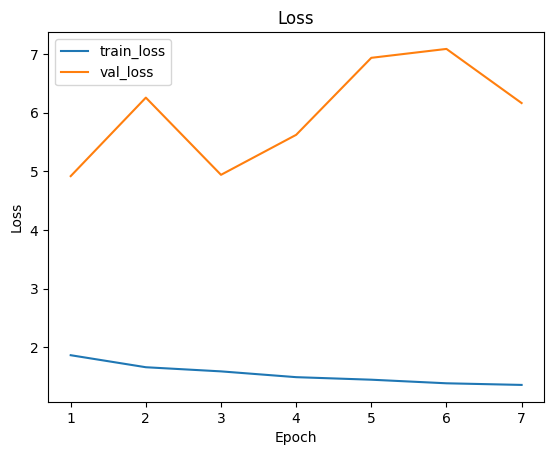

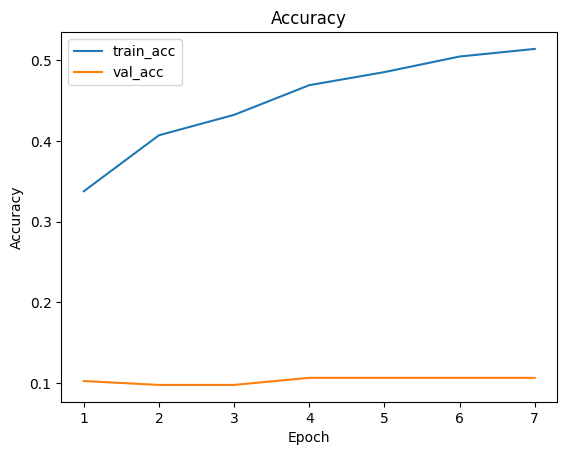

In [19]:
# Unfreeze last ~20 layers as a simple proxy for "top block"
base.trainable = True
for layer in base.layers[:-20]:
    layer.trainable = False

# Compile with small LR
tl_model.compile(optimizer=tf.keras.optimizers.Adam(1e-4),
                 loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Callbacks
cbs = [
    tf.keras.callbacks.EarlyStopping(monitor='val_accuracy', patience=3, restore_best_weights=True),
    tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2),
    tf.keras.callbacks.ModelCheckpoint('/mnt/data/tl_ft_best.keras', monitor='val_accuracy',
                                       save_best_only=True)
]
history_ft_basic = tl_model.fit(x_train_r, y_train_c, validation_split=0.1,
                                epochs=10, batch_size=128, callbacks=cbs, verbose=2)
plot_history(history_ft_basic)

### Exercise 13 — Gradual Unfreezing
1. Start from the **best checkpoint** from Exercise 12.
2. Unfreeze **more layers** (e.g., last 50 layers).
3. Use an even **smaller LR** (e.g., `5e-5`).
4. Train a few more epochs with the same callbacks.

In [ ]:
# === Your work: Exercise 13 ===
# tl_model = tf.keras.models.load_model('/mnt/data/tl_ft_best.keras')
# base = tl_model.layers[3]  # (Re-retrieve the base if needed; adjust index if model structure changes)
# base.trainable = True
# for layer in base.layers[:-50]:
#     layer.trainable = False
# tl_model.compile(optimizer=tf.keras.optimizers.Adam(5e-5),
#                  loss='sparse_categorical_crossentropy', metrics=['accuracy'])
# history_ft_more = tl_model.fit(x_train_r, y_train_c, validation_split=0.1,
#                                epochs=6, batch_size=128, callbacks=cbs, verbose=2)
# plot_history(history_ft_more)

#### ✅ Correction — Exercise 13

In [ ]:
# Reload the best model from previous step to continue fine-tuning
tl_model = tf.keras.models.load_model('/mnt/data/tl_ft_best.keras')

# Find the base (MobileNetV2) inside tl_model by type
base = None
for lyr in tl_model.layers:
    if isinstance(lyr, tf.keras.Model) and 'MobileNetV2' in lyr.name:
        base = lyr
        break
# Fallback: if not found by name, assume the second layer is the base (depends on build above)
if base is None and len(tl_model.layers) > 1:
    base = tl_model.layers[1]

# Unfreeze deeper
base.trainable = True
for layer in base.layers[:-50]:
    layer.trainable = False

tl_model.compile(optimizer=tf.keras.optimizers.Adam(5e-5),
                 loss='sparse_categorical_crossentropy', metrics=['accuracy'])
history_ft_more = tl_model.fit(x_train_r, y_train_c, validation_split=0.1,
                               epochs=6, batch_size=128, callbacks=cbs, verbose=2)
plot_history(history_ft_more)

### Exercise 14 — Regularization & Head Re-Warm
- **Re-warm the head:** briefly train only the head with a slightly higher LR to stabilize after unfreezing.
- Add **Dropout tuning** (e.g., 0.3–0.5) on the head.
- Try **AdamW** with small weight decay (if available) or keep Adam if not.

In [ ]:
# === Your work: Exercise 14 ===
# from tensorflow.keras import layers, Model
# # Rebuild a small head with configurable dropout:
# head_inputs = tl_model.input
# x = tl_model.layers[-3].output  # Grab GAP output if head structure matches; adjust if needed
# x = layers.Dropout(0.3)(x)
# outputs = layers.Dense(10, activation='softmax')(x)
# tl_model_rw = Model(head_inputs, outputs)
# tl_model_rw.compile(optimizer=tf.keras.optimizers.Adam(3e-4),
#                     loss='sparse_categorical_crossentropy', metrics=['accuracy'])
# history_rw = tl_model_rw.fit(x_train_r, y_train_c, validation_split=0.1,
#                              epochs=3, batch_size=128, verbose=2)
# plot_history(history_rw)

#### ✅ Correction — Exercise 14

In [ ]:
from tensorflow.keras import layers, Model

# Freeze base again to re-warm head briefly
for layer in base.layers:
    layer.trainable = False

# Rebuild head on top of the base output
gap_output = tl_model.layers[-3].output  # GlobalAveragePooling2D before final Dense (based on earlier build)
x = layers.Dropout(0.3)(gap_output)
new_outputs = layers.Dense(10, activation='softmax')(x)
tl_model_rw = Model(inputs=tl_model.input, outputs=new_outputs)

tl_model_rw.compile(optimizer=tf.keras.optimizers.Adam(3e-4),
                    loss='sparse_categorical_crossentropy', metrics=['accuracy'])
history_rw = tl_model_rw.fit(x_train_r, y_train_c, validation_split=0.1,
                             epochs=3, batch_size=128, verbose=2)
plot_history(history_rw)

### Exercise 15 — Evaluate the Best Fine-Tuned Model
- Load the **best checkpoint** from Exercise 12/13 if it performs best, or use your final model.
- Evaluate on the test set and print a classification report.

In [ ]:
# === Your work: Exercise 15 ===
# best_model = tf.keras.models.load_model('/mnt/data/tl_ft_best.keras')
# test_loss_ft, test_acc_ft = best_model.evaluate(x_test_r, y_test_c, verbose=0)
# print("Fine-tuned Test accuracy:", round(float(test_acc_ft), 4))
# y_pred_ft = np.argmax(best_model.predict(x_test_r, verbose=0), axis=1)
# cm_ft = confusion_matrix(y_test_c, y_pred_ft)
# plot_confusion_matrix(cm_ft, class_names=class_names)
# print(classification_report(y_test_c, y_pred_ft, target_names=class_names))

#### ✅ Correction — Exercise 15

In [ ]:
best_model = tf.keras.models.load_model('/mnt/data/tl_ft_best.keras')
test_loss_ft, test_acc_ft = best_model.evaluate(x_test_r, y_test_c, verbose=0)
print("Fine-tuned Test accuracy:", round(float(test_acc_ft), 4))

y_pred_ft = np.argmax(best_model.predict(x_test_r, verbose=0), axis=1)
cm_ft = confusion_matrix(y_test_c, y_pred_ft)
plot_confusion_matrix(cm_ft, class_names=class_names)
print(classification_report(y_test_c, y_pred_ft, target_names=class_names))

---
### Checklist & Tips for Fine-Tuning
- Start with the head only, then unfreeze top blocks.
- Use small LRs (`1e-4` → `5e-5` → `1e-5`) as you unfreeze more.
- Keep strong callbacks: EarlyStopping + ReduceLROnPlateau + ModelCheckpoint.
- Track validation metrics; avoid overfitting with dropout and weight decay (if available).
- If accuracy drops after unfreezing, re-freeze and **re-warm the head** briefly.